In [1]:
import  torch 
torch.cuda.get_device_name(torch.cuda.current_device()) # Tesla T4

'NVIDIA A100-PCIE-40GB'

In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
configure_matplotlib()
SAVE_FIGURES = True
fig_path = RETROSEQ_FIGURE_DIR
from functools import partial
save_figure = partial(save_figure, dir_path=fig_path)
cpm_scl = CPM_SCL

PROJECT_ROOT: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics
CODE_DIR: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/code
CODE_DIR exists: True
Python path includes CODE_DIR: True


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import scvi
import anndata
from sklearn.neighbors import NearestNeighbors

import processing, utils, plotting, heatmap
import pseudoclusters, test_structures
print(f"scanpy version: {sc.__version__}")
print(f"scvi version: {scvi.__version__}")

scanpy version: 1.10.4
scvi version: 1.2.2.post2


In [4]:
print("Loading retroseq and snRNA data...")
filename = os.path.join(RETROSEQ_DATA_DIR, 'retroseq_updated_filtered.h5ad')
adata_retro = sc.read_h5ad(filename)

# Load snRNA data for gene filtering
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_sc = sc.read_h5ad(myfilename)
adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})

# Filter genes to match snRNA data
keepgenes = np.intersect1d(list(adata_sc.var_names), list(adata_retro.var_names))
print(f"Number of shared genes: {keepgenes.shape[0]}")
adata_retro = adata_retro[:, keepgenes].copy()

# Check normalization of reference dataset
print(f"Reference dataset sum per cell: {np.mean(np.sum(adata_sc.layers['BN'], 1)):.4f}")

Loading retroseq and snRNA data...
Number of shared genes: 1500
Reference dataset sum per cell: 1.0000


/scratch/fast/5195245/ipykernel_3510004/1682358927.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


In [5]:
orig_proj_target = list( adata_retro.obs['injection_site'])

In [6]:
mapping = {
    cat: cat.title()
    for cat in adata_retro.obs['injection_site'].cat.categories
}

# Apply it
adata_retro.obs['injection_site'] = (
    adata_retro.obs['injection_site']
    .cat.rename_categories(mapping)
)

In [7]:
adata_retro.X.max(), adata_retro.X.min()

(np.float64(5696.0), np.float64(0.0))

Text(0.5, 1.0, 'kind of zero inflated here ')

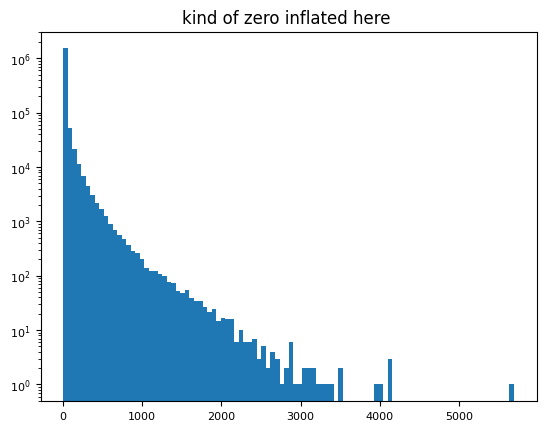

In [8]:
plt.hist(adata_retro.X.toarray().flatten(), bins = 100);
plt.yscale('log')
plt.title('kind of zero inflated here ')

In [9]:
#fit scvi ~ 30 sec i
print("Fitting SCVI model for dimensionality reduction...")
scvi.settings.seed = 1
scvi.model.SCVI.setup_anndata(
    adata_retro, 
    batch_key='external_donor_name', 
#     categorical_covariate_keys=['gender']
)
model = scvi.model.SCVI(adata_retro, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train()
print("SCVI model training complete")
SCVI_LATENT_KEY = "X_scVI"
adata_retro.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

[rank: 0] Seed set to 1


Fitting SCVI model for dimensionality reduction...


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning: Category 8 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT:

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


SCVI model training complete


Creating UMAP visualization...


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)
/scratch/fast/5195245/ipykernel_3510004/3325840655.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


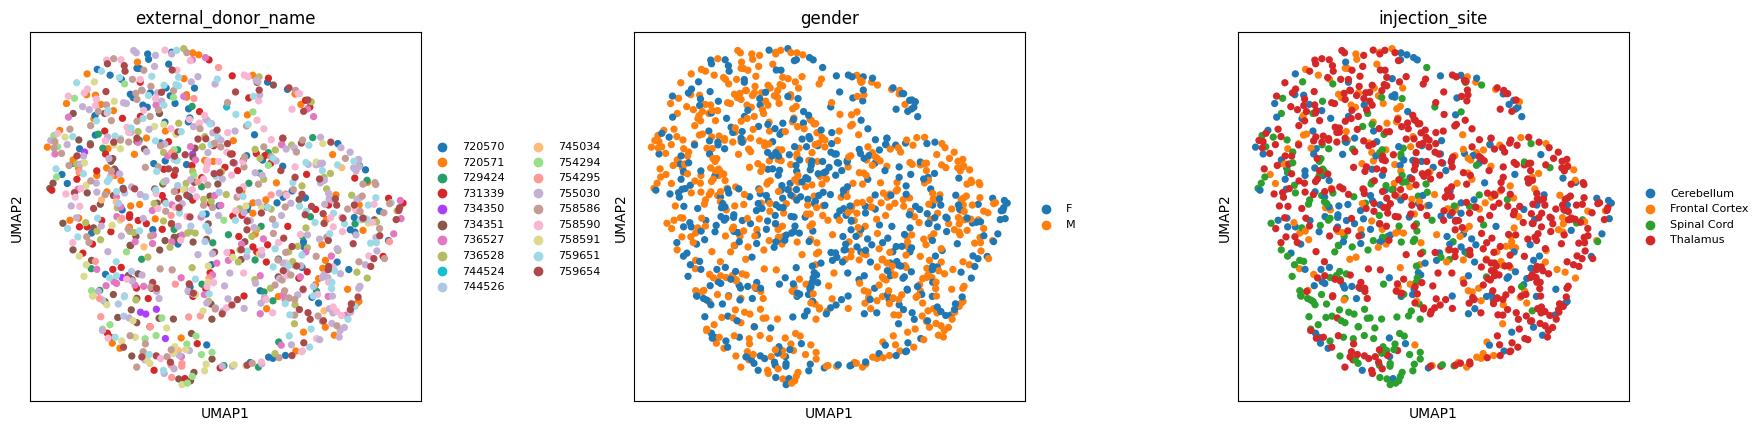

In [10]:
# UMAP Visualization
print("Creating UMAP visualization...")

# Compute neighbors and UMAP embedding
sc.pp.neighbors(adata_retro, use_rep=SCVI_LATENT_KEY)#, n_neighbors=50)
sc.tl.umap(adata_retro, random_state=210)

# Plot UMAP with metadata
ax = sc.pl.umap(adata_retro, color=["external_donor_name", "gender", 'injection_site'], 
           ncols=3, show=False)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()

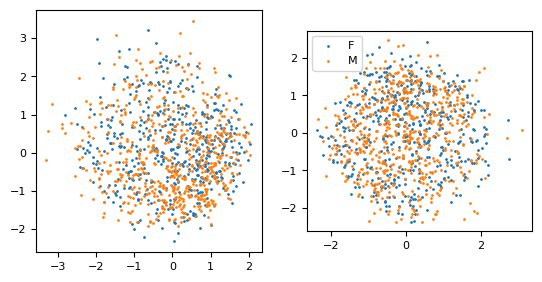

In [11]:
plt.subplot(1,2,1);
for s in np.unique(np.array(adata_retro.obs['gender'])):
    ids = adata_retro.obs['gender']==s
    plt.scatter(adata_retro.obsm['X_scVI'][ids,0], adata_retro.obsm['X_scVI'][ids,1],s=1, label = s)
    plt.gca().set_aspect('equal')
plt.subplot(1,2,2);
for s in np.unique(np.array(adata_retro.obs['gender'])):
    ids = adata_retro.obs['gender']==s
    plt.scatter(adata_retro.obsm['X_scVI'][ids,2], adata_retro.obsm['X_scVI'][ids,3],s=1, label = s)
    plt.gca().set_aspect('equal')
plt.legend()

In [12]:
# Clean projection target Categories
# Define categories and handle thalamus
cate_list = ["Frontal Cortex", 'Cerebellum', "Spinal Cord", 'Thalamus']
adata_retro.obs['injection_site'].replace('thalamus', np.nan, inplace=True)
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].astype('category')
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].cat.remove_unused_categories()
adata_retro.uns.pop('injection_site_colors', None)
adata_retro.obs["injection_site"] = pd.Categorical(
    adata_retro.obs["injection_site"],
    categories=cate_list[:-1],
    ordered=True
)
print("projection target:")
print(adata_retro.obs['injection_site'].value_counts())

# Create color dictionary
cm = plt.cm.get_cmap('tab10')
default_colors = list(cm.colors)
col_list = default_colors[:3]
col_dict = {cate_list[i]: col_list[i] for i in range(len(cate_list))[:3]}
col_dict['others'] = 'white'

projection target:
injection_site
Cerebellum        210
Spinal Cord       184
Frontal Cortex    173
Name: count, dtype: int64


/scratch/fast/5195245/ipykernel_3510004/3789219233.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_retro.obs['injection_site'].replace('thalamus', np.nan, inplace=True)
/scratch/fast/5195245/ipykernel_3510004/3789219233.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab10')


/scratch/fast/5195245/ipykernel_3510004/1834731600.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/BN_results.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/BN_results.png


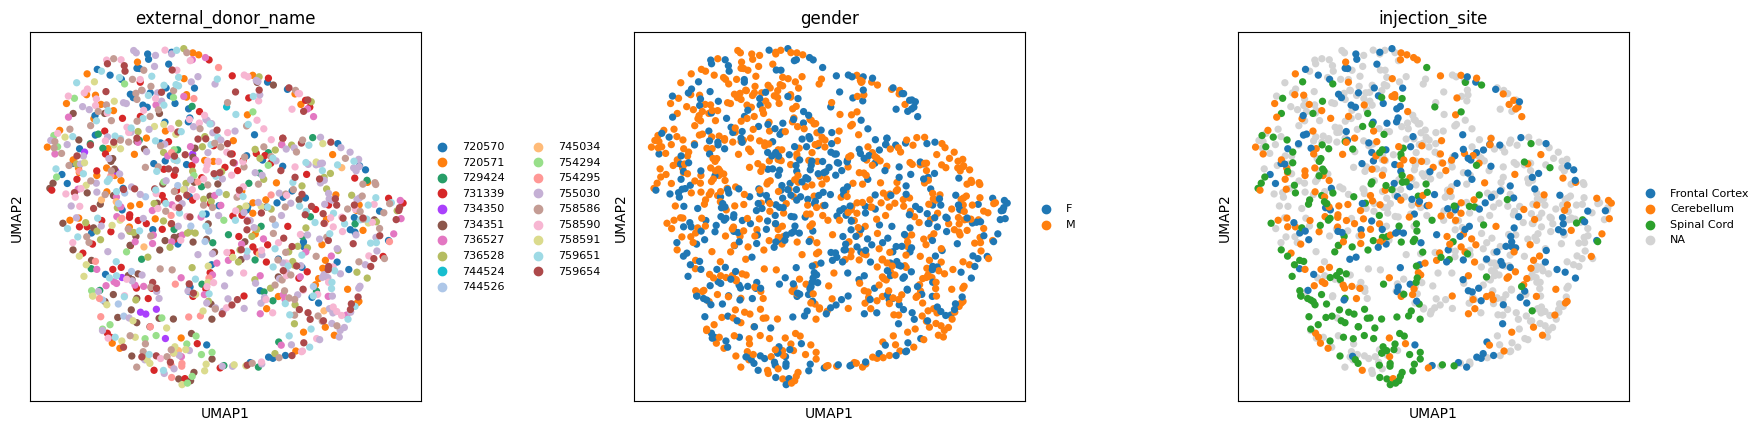

In [13]:
# Plot UMAP with metadata
ax = sc.pl.umap(adata_retro, color=["external_donor_name", "gender", 'injection_site'], 
           ncols=3, show=False)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()
save_figure("BN_results")

Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/injection_site_umap.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/injection_site_umap.png


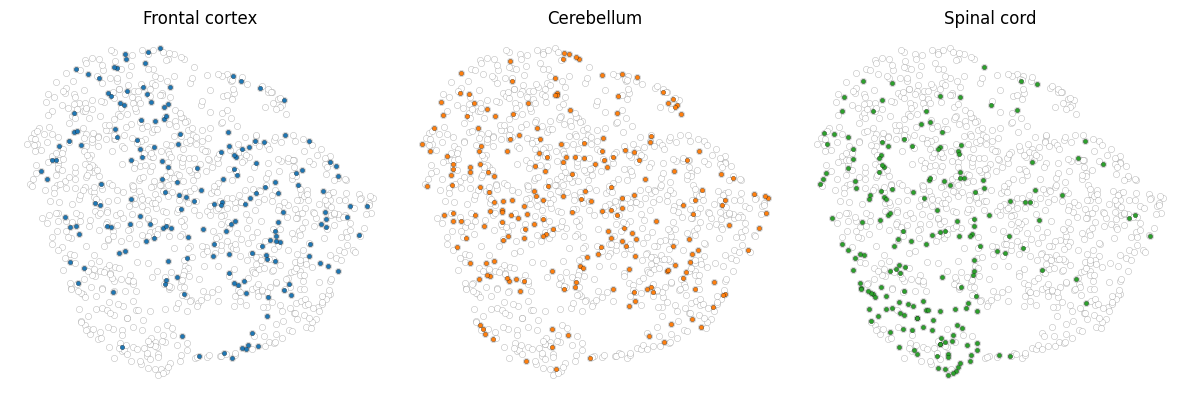

In [14]:
# projection target Visualization on UMAP
umap_coords = adata_retro.obsm['X_umap']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    # Highlight cells from this projection target
    mask = adata_retro.obs['injection_site'] == k
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
               color=col_dict[k], s=10, alpha=1, label=k,
               edgecolor='k', linewidth=.2)
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure("injection_site_umap")

In [15]:
# Add Normalized Layer and Save
print("Adding normalized layer (BN) and saving data...")
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
adata_retro.layers["BN"] = model.get_normalized_expression(adata_retro, 
                                                           transform_batch=all_batches, library_size= 1)

savefilename = RETROSEQ_DATA_DIR+"/retro_BN_d4_1500genes.h5ad"
adata_retro.write(savefilename)
print(f"Data saved to: {savefilename}")

adata_retro_BN = adata_retro.copy()
adata_retro_BN.X = adata_retro.layers['BN'].copy()
print("Created copy with BN as main layer")

Adding normalized layer (BN) and saving data...
Data saved to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/data/retroseq/retro_BN_d4_1500genes.h5ad
Created copy with BN as main layer


In [16]:
# Differential Expression Analysis
print("Performing differential expression analysis between projection target...")
mask = (
    adata_retro_BN.var_names.str.startswith("Gm") |
    adata_retro_BN.var_names.str.endswith("Rik")|
    adata_retro_BN.var_names.str.startswith("CN"))

adata_de = adata_retro_BN[:, ~mask]
sc.tl.rank_genes_groups(
    adata_de,
    groupby="injection_site",
    method="wilcoxon",
#     min_in_group_fraction=0.20,
#     max_out_group_fraction=0.90,
    key_added="rank_genes_groups_filtered"
)

Performing differential expression analysis between projection target...


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 1091 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/scratch/fast/5195245/ipykernel_3510004/1960263728.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


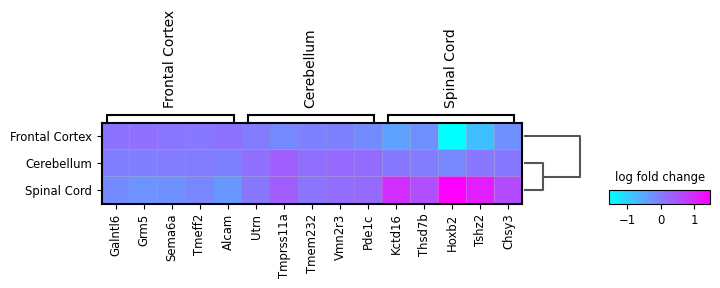

In [17]:


sc.pl.rank_genes_groups_matrixplot(
    adata_de,
    key="rank_genes_groups_filtered",
    n_genes=5,
    cmap="cool",
    groupby="injection_site",
    values_to_plot="logfoldchanges",
    # min_logfoldchange=1,   # <-- only plot genes with lo2FC ≥ 1.0, i.e.,g FC is x2
    show=False
)
plt.tight_layout()


categories: Frontal Cortex, Cerebellum, Spinal Cord
var_group_labels: Frontal Cortex, Spinal Cord
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/de_matrix_enhanced.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/de_matrix_enhanced.png


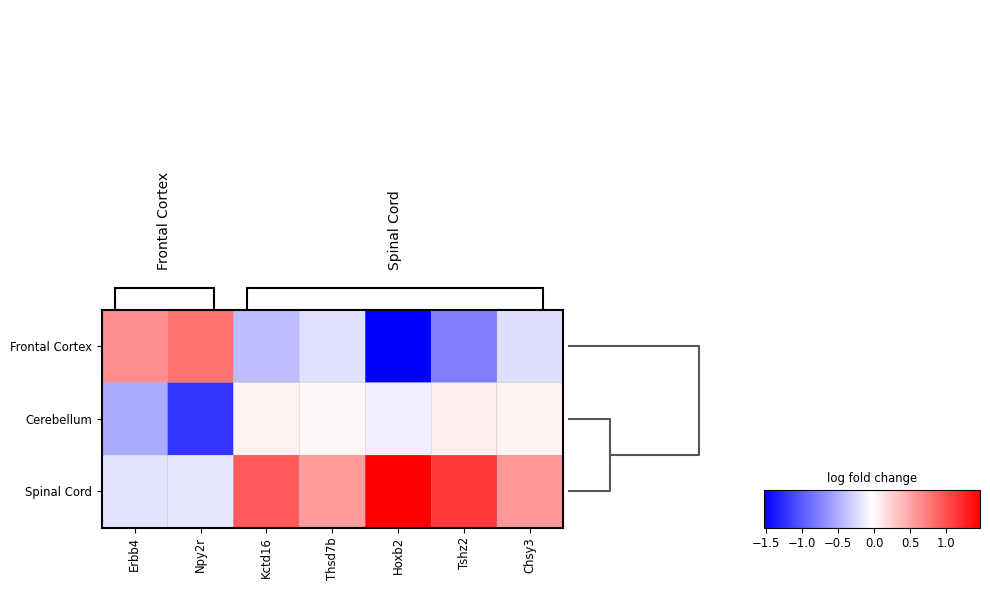


Top 5 DE genes for group 'Frontal Cortex' (LFC ≥ 0.5):
['Erbb4', 'Npy2r']

Top 5 DE genes for group 'Cerebellum' (LFC ≥ 0.5):
[]

Top 5 DE genes for group 'Spinal Cord' (LFC ≥ 0.5):
['Kctd16', 'Thsd7b', 'Hoxb2', 'Tshz2', 'Chsy3']


In [18]:
T = 5
min_lfc  = 0.5          # minimum log‑fold‑change to include
key      = "rank_genes_groups_filtered"  # DE results slot to use
cates    = ['Frontal Cortex', 'Cerebellum', 'Spinal Cord', 'nan']  # desired order
adata_de.uns['dendrogram_injection_site']['categories_ordered'] = cates[:-1]

fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.rank_genes_groups_matrixplot(
    adata_de,
    key=key,
    groupby="injection_site",
    values_to_plot="logfoldchanges",
    n_genes=T,
    cmap='bwr',
    min_logfoldchange=min_lfc,
    ax=ax,
    show=False
)
plt.tight_layout()
save_figure("de_matrix_enhanced")
plt.show()

for grp in adata_de.obs['injection_site'].cat.categories:
    df = sc.get.rank_genes_groups_df(adata_de, group=grp, key=key)
    df_filt = df[df['logfoldchanges'] >= min_lfc]
    top_genes = df_filt['names'].tolist()[:T]
    
    print(f"\nTop {T} DE genes for group '{grp}' (LFC ≥ {min_lfc}):")
    print(top_genes)


Post-scaling gene std mean: 0.9991, min: 0.9029, max: 0.9995
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/pca_metadata.svg


/scratch/fast/5195245/ipykernel_3510004/2265349739.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/pca_metadata.png


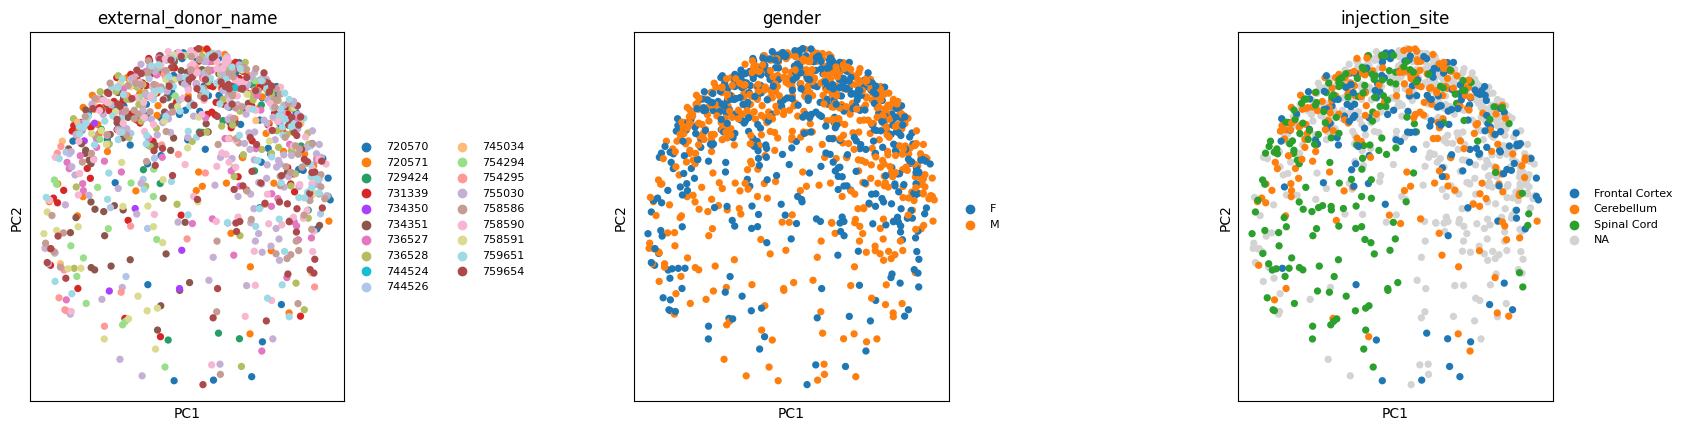

In [19]:
# PCA Analysis
adata_retro_BN.raw = adata_retro_BN.copy()  # raw has total 1 gene per sample
sc.pp.scale(adata_retro_BN, zero_center=True, max_value=10)
sc.pp.pca(adata_retro_BN, n_comps=50, svd_solver='arpack')
gene_std = np.std(adata_retro_BN.X, 0)
print(f"Post-scaling gene std mean: {np.mean(gene_std):.4f}, min: {np.min(gene_std):.4f}, max: {np.max(gene_std):.4f}")
# Plot PCA with metadata
ax = sc.pl.pca(adata_retro_BN, color=['external_donor_name', "gender",'injection_site'], show=False)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()
save_figure("pca_metadata")
plt.show()

Visualizing key genes on PCA...
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/pca_key_genes.svg


/scratch/fast/5195245/ipykernel_3510004/1169217820.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/pca_key_genes.png


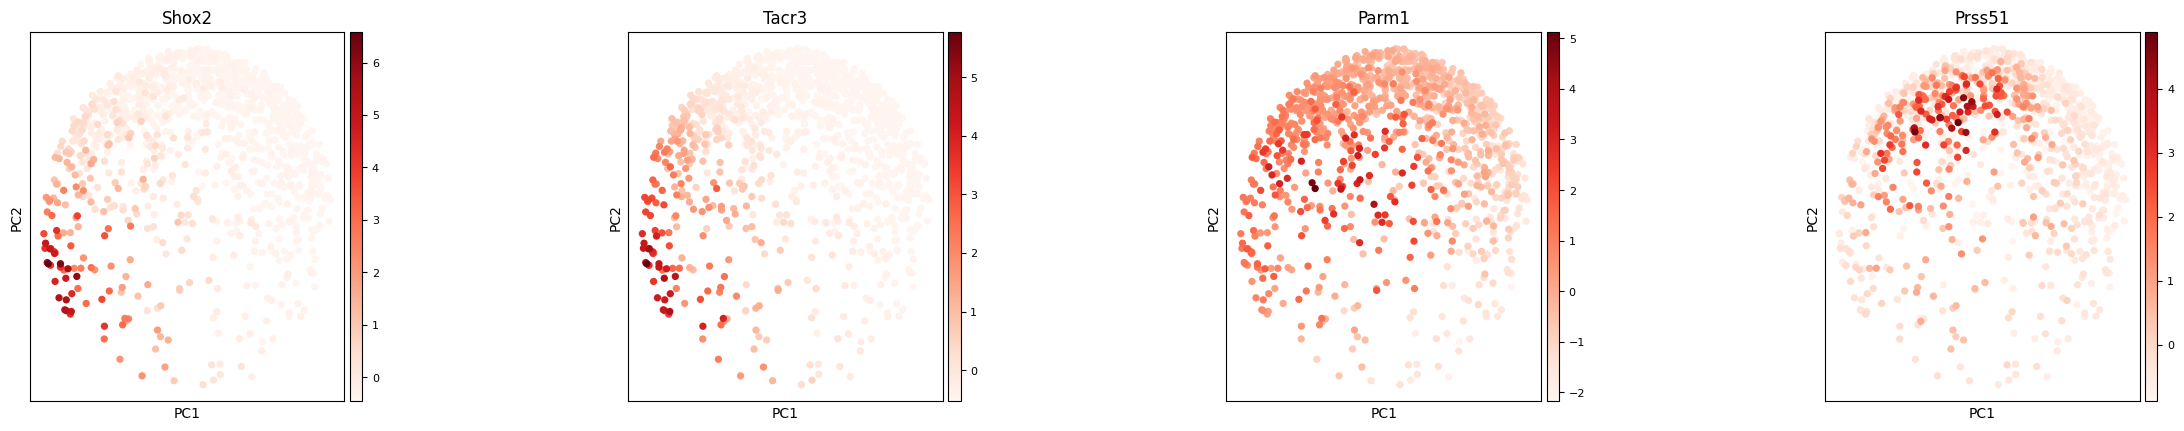

In [20]:
# Visualize Key Genes on PCA
print("Visualizing key genes on PCA...")

key_genes = ['Shox2', 'Tacr3', 'Parm1', 'Prss51']
# fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax = sc.pl.pca(adata_retro_BN, color=key_genes, cmap='Reds', show=False, use_raw=False)
for a in ax:a.set_aspect('equal')
plt.tight_layout()
save_figure("pca_key_genes")
# plt.show()

# (optional) DE from scvi model 

In [21]:
print("Performing differential expression analysis between projection target...")
mask = (
    adata_retro_BN.var_names.str.startswith("Gm") |
    adata_retro_BN.var_names.str.endswith("Rik")|
    adata_retro_BN.var_names.str.startswith("CN"))

adata_de = adata_retro_BN[:, ~mask]

de_change_dict = dict()
for k in np.unique(adata_de.obs["injection_site"].values.astype(str))[:3]:
    cell_idx_A = adata_de.obs["injection_site"] == k
    cell_idx_B = adata_de.obs["injection_site"] != k
    print(k)
    de_change_dict[k] = model.differential_expression(idx1 = cell_idx_A, idx2 = cell_idx_B, mode = 'change')

Performing differential expression analysis between projection target...
Cerebellum


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

Frontal Cortex


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

Spinal Cord


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
for k in np.unique(adata_retro_BN.obs["injection_site"].values.astype(str))[:3]:
    print(de_change_dict[k].index[:10])

Index(['Abcb5', 'Gm29685', 'Lockd', 'Dnase2b', 'Gm44127', 'Npy2r', 'Tacr3',
       'Grp', 'Gm38405', 'Rasl11a'],
      dtype='object')
Index(['Adamts16', 'Defb19', 'Gm29685', 'Prkce', 'Tacr3', 'AY702103', 'Lockd',
       'Mbl2', 'Grp', 'Pappa2'],
      dtype='object')
Index(['Slit1', 'Tacr3', 'Rspo2', 'Npy2r', 'Tent5a', 'Gad2', 'Glra3', 'Lockd',
       'Efemp1', 'Grp'],
      dtype='object')


In [23]:
de_change_dict[k]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
Slit1,0.9776,0.0224,3.776039,0.000057,0.000437,0.0,0.25,-3.454596,-3.591852,2.171046,-9.813698,5.797210,2.483696,8.817680,0.326087,0.395580,1.223204,3.869183,True
Tacr3,0.9766,0.0234,3.731341,0.001248,0.000177,0.0,0.25,4.745855,5.181903,4.561981,-12.326704,17.012135,14.315217,2.066298,0.288043,0.070718,6.763561,0.814957,True
Rspo2,0.9736,0.0264,3.607636,0.000519,0.000076,0.0,0.25,3.323382,3.652273,4.080978,-11.271631,13.938222,3.902174,0.470718,0.119565,0.056354,2.228065,0.188837,True
Npy2r,0.9736,0.0264,3.607636,0.000003,0.000038,0.0,0.25,-1.486163,-1.406160,5.660185,-21.558815,15.985592,0.000000,0.680663,0.000000,0.007735,0.000000,0.195156,True
Tent5a,0.9728,0.0272,3.576961,0.000033,0.000432,0.0,0.25,-4.393900,-4.557729,3.404920,-14.097713,8.606970,0.005435,2.218785,0.005435,0.059669,0.002805,0.864657,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ptprd,0.6816,0.3184,0.761135,0.017730,0.014064,0.0,0.25,0.320754,0.311172,0.520388,-1.505692,2.034924,730.733696,568.255249,0.994565,0.997790,326.808929,240.315758,False
Pcdh9,0.6750,0.3250,0.730887,0.012277,0.011069,0.0,0.25,0.143660,0.171956,0.580344,-2.263976,2.202808,397.326087,376.213260,0.994565,0.998895,178.828812,156.889954,False
Trps1,0.6746,0.3254,0.729065,0.002714,0.002697,0.0,0.25,-0.025033,-0.007964,0.635807,-2.656507,3.244831,57.190217,65.337017,0.842391,0.883978,27.358004,28.052779,False
Schip1,0.6530,0.3470,0.632252,0.002698,0.002637,0.0,0.25,-0.006330,0.023178,0.633769,-3.490632,2.033430,56.070652,65.088398,0.875000,0.891713,28.129028,29.030564,False


# add: which genes are consistently detected by both methods? 

# data integration with snRNA!

In [24]:
# Prepare for reference dataset

adata_sc = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_BN = adata_sc.copy()
adata_sc_BN.X = adata_sc.layers['BN'].copy()
adata_sc_BN.raw = adata_sc_BN.copy()

# Load pseudocluster information
print("Loading pseudocluster information...")
arc_path = TMP_OUT_DIR+'/cellID_pc_0722.csv'
arcinfo = pd.read_csv(arc_path)
arcinfo = arcinfo.set_index('cellID')
adata_sc_BN.obs['pc'] = arcinfo['pseudoclusters'].reindex(adata_sc_BN.obs.index)
print(f"Added pseudocluster scores to {adata_sc_BN.n_obs} cells")
del(adata_sc)# Free memory

Preparing for data integration with snRNA-seq...
Loading pseudocluster information...
Added pseudocluster scores to 4895 cells


In [25]:
np.sum(adata_retro_BN.raw.X,1)

array([1.        , 1.        , 1.        , ..., 0.99999994, 1.        ,
       1.        ], dtype=float32)

In [26]:
# Prepare Retroseq Data for Integration
adata_retro_BN.X = adata_retro_BN.raw.X.copy() # sample sum is 1
adata_retro_BN = adata_retro_BN[:, adata_sc_BN.var_names].copy()
adata_retro_BN.obs.rename(columns={'gender': 'sex'}, inplace=True)

print(f"Retroseq sum per cell: {np.mean(np.sum(adata_retro_BN.X, 1)):.4f}")
print(f"Reference sum per cell: {np.mean(np.sum(adata_sc_BN.X, 1)):.4f}")

Retroseq sum per cell: 1.0000
Reference sum per cell: 1.0000


## rescaling (define `adata_retro_BN_norm` and `adata_sc_BN_norm`)  and injest

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'retroseq PCA after ingest')

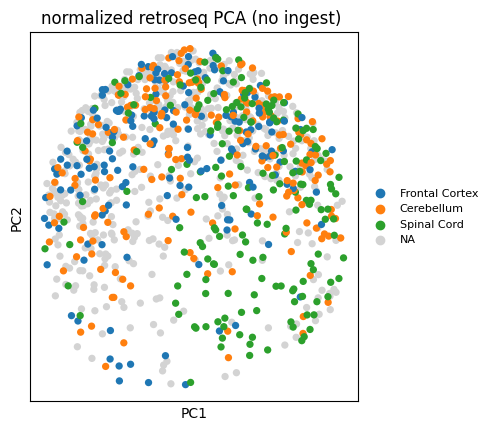

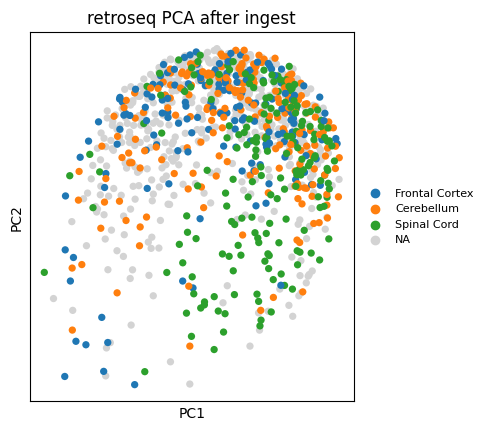

In [37]:
# Get reference statistics from the original reference data
X_ref_orig = adata_sc_BN.X.copy()
ref_means = X_ref_orig.mean(axis=0)           # shape (n_genes,)
ref_stds = X_ref_orig.std(axis=0, ddof=0)     # shape (n_genes,)

# Apply the SAME normalization to both datasets
# 1. Normalize reference data
adata_sc_BN_norm = adata_sc_BN.copy()
X_ref = (X_ref_orig - ref_means) / ref_stds
X_ref = np.clip(X_ref, -10, 10)
adata_sc_BN_norm.X = X_ref

# 2. Normalize query data using SAME statistics
adata_retro_BN_norm = adata_retro_BN.copy()
Xq = adata_retro_BN_norm.X.toarray() if hasattr(adata_retro_BN_norm.X, "toarray") else adata_retro_BN_norm.X
Xq = (Xq - ref_means) / ref_stds
Xq = np.clip(Xq, -10, 10)
adata_retro_BN_norm.X = Xq

# 3. Compute PCA on reference and then project query
sc.pp.pca(adata_sc_BN_norm, n_comps=50, svd_solver='arpack')
sc.pp.neighbors(adata_sc_BN_norm)

#### optional plot
# # plot the query original PCA
# sc.pp.pca(adata_retro_BN_norm, n_comps=50, svd_solver='arpack')
# a = sc.pl.pca(adata_retro_BN_norm, show = False, color = 'injection_site')
# a.set_aspect('equal')
# a.set_title('normalized retroseq PCA (no ingest) ')




# 4. Project query into reference PCA space
sc.tl.ingest(adata_retro_BN_norm, adata_sc_BN_norm, embedding_method='pca', inplace=True)



#### optional plot
# # the query PCA after ingest  
# a = sc.pl.pca(adata_retro_BN_norm, show = False, color = 'injection_site')
# a.set_aspect('equal')
# a.set_title('retroseq PCA after ingest')


### nearest neighbor to transfer the pseudoclusters

Text(0.5, 1.0, 'new PCA , AFTER ingegst')

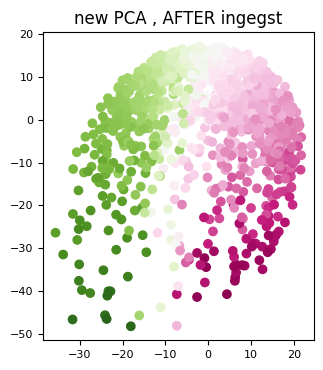

In [48]:
# Transfer pseudocluster scores using k nearest neighbors
k=100 # turns out this number really doesnt matter too much 

nbrs = NearestNeighbors(n_neighbors=k).fit(adata_sc_BN_norm.obsm['X_pca'])
dists, idxs = nbrs.kneighbors(adata_retro_BN_norm.obsm['X_pca'])
ref_scores = adata_sc_BN_norm.obs['pc'].values
weights = 1 / (dists + 1e-12)
weights /= weights.sum(axis=1, keepdims=True)

plt.figure(figsize = (4,4))
adata_retro_BN_norm.obs['pc'] = (ref_scores[idxs] * weights).sum(axis=1)
plt.scatter(adata_retro_BN_norm.obsm['X_pca'][:,0],adata_retro_BN_norm.obsm['X_pca'][:,1],
            c = adata_retro_BN_norm.obs['pc'], cmap = 'PiYG')
plt.gca().set_aspect('equal');plt.title('new PCA , AFTER ingegst')

Visualizing integration results...
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/integration_results.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/integration_results.png


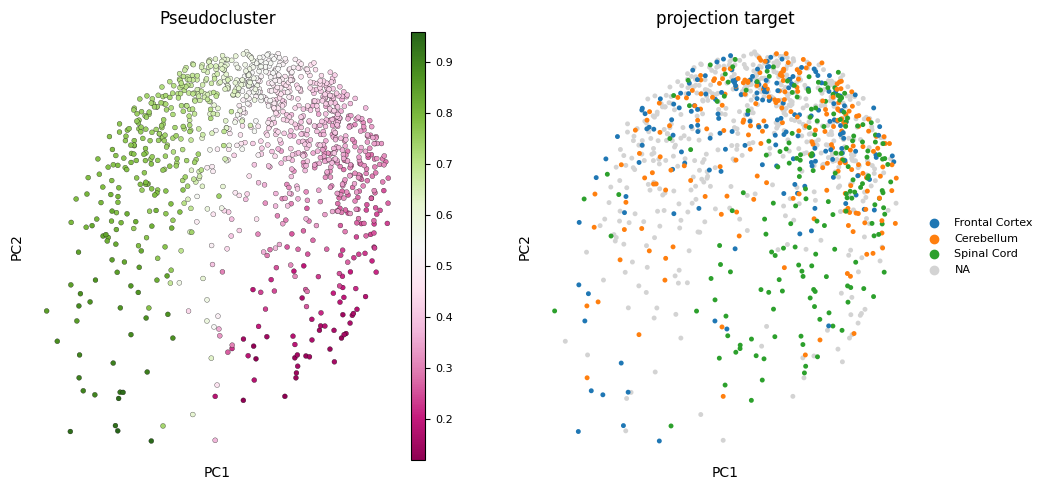

In [49]:
print("Visualizing integration results...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Pseudocluster
sc.pl.pca(
    adata_retro_BN_norm,
    ax=axes[0],
    color='pc',
    title='Pseudocluster',
    show=False,
    s=50,edgecolor='k', linewidth=0.2, 
    cmap='PiYG'
)
axes[0].set_aspect('equal')
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_xticks([])
axes[0].set_yticks([])


# 2) projection target
sc.pl.pca(
    adata_retro_BN_norm,
    ax=axes[1],
    color='injection_site',
    title='projection target',
    show=False,
    s=50,
    cmap='PiYG'
)
axes[1].set_aspect('equal')
axes[1].set_aspect('equal')
for spine in axes[1].spines.values():
    spine.set_visible(False)
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
save_figure("integration_results")
# plt.show()


In [50]:
# Concatenate Datasets for Joint Analysis
print("Concatenating datasets for joint analysis...")

# Concatenate with batch label
adata_concat = anndata.concat(
    [adata_sc_BN_norm, adata_retro_BN_norm], 
    label="batch", 
    keys=["snRNA", "retro"]
)

# Add projection target info (NA for snRNA cells)
adata_concat.obs['injection_site'] = list(np.repeat('NA', len(adata_sc_BN_norm))) + list(adata_retro_BN_norm.obs['injection_site'])



Concatenating datasets for joint analysis...


Visualizing integration results...
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/integration_results_with_BN.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/integration_results_with_BN.png


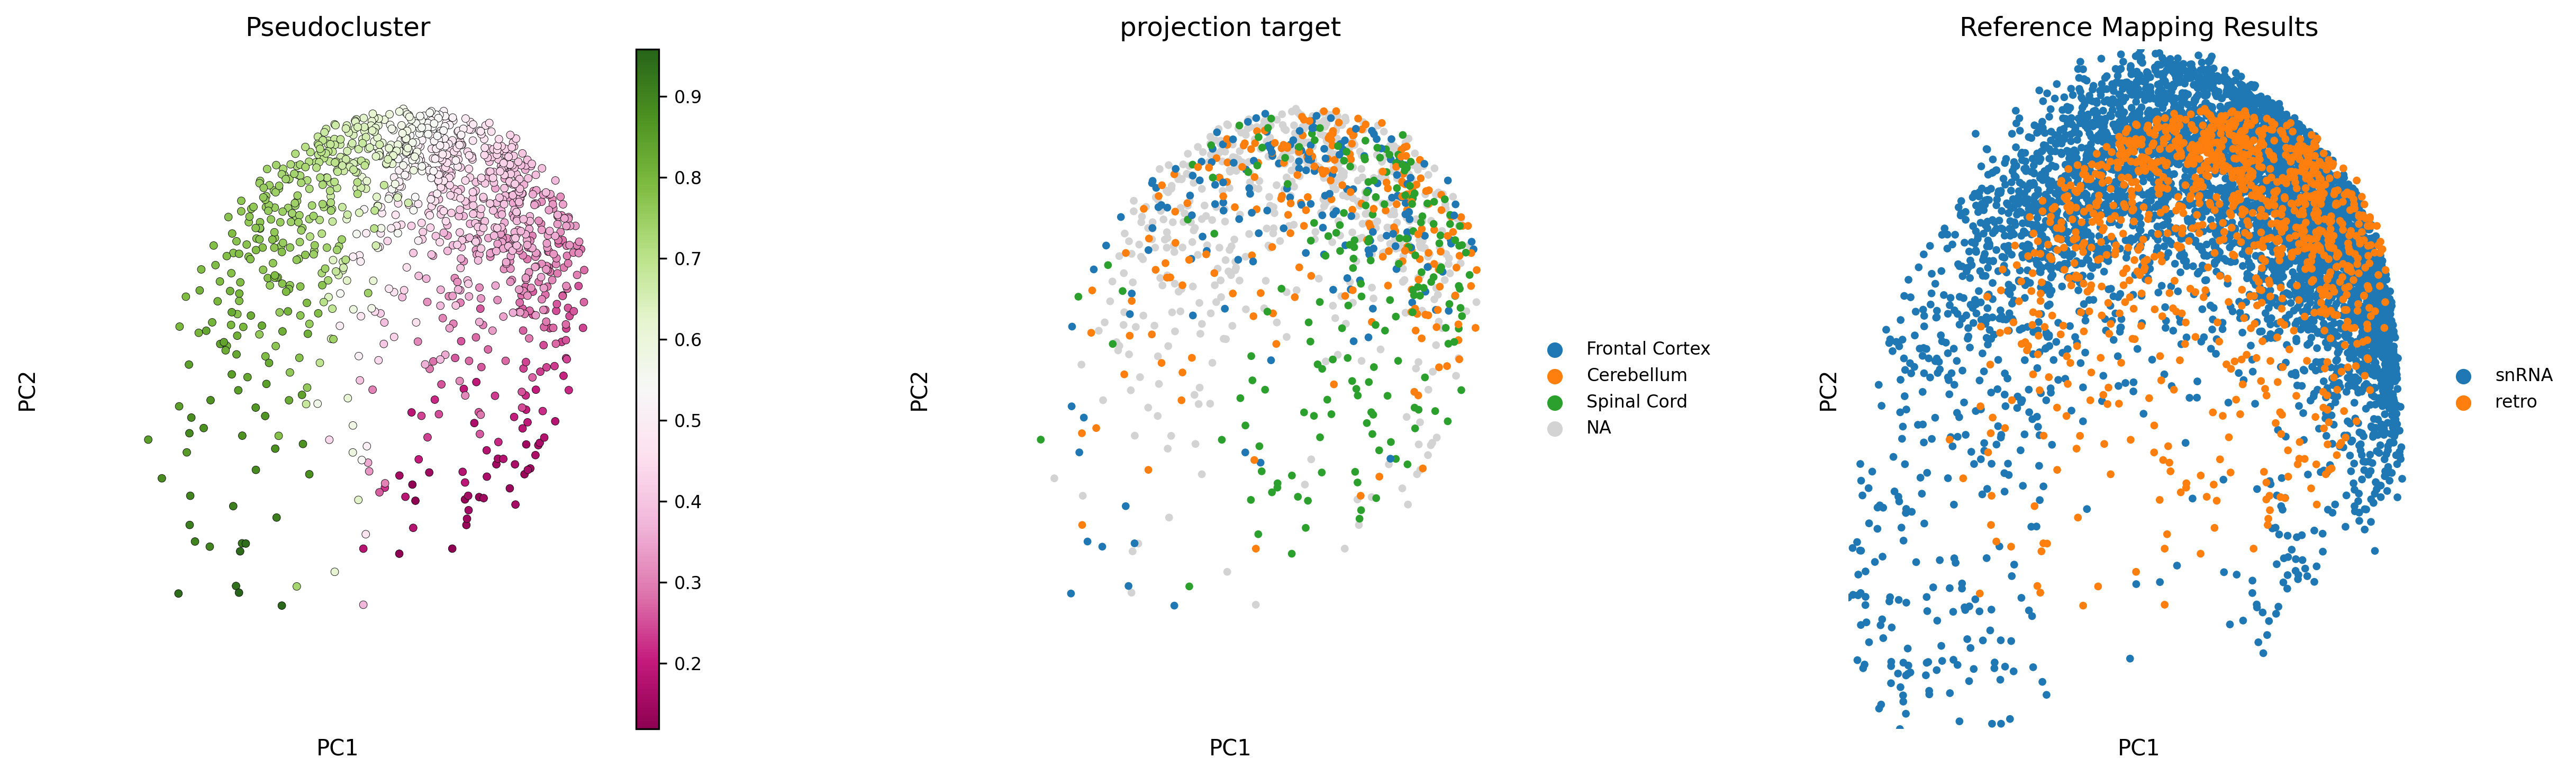

In [51]:
print("Visualizing integration results...")
minx = adata_concat.obsm['X_pca'][:,0].min()
maxx = adata_concat.obsm['X_pca'][:,0].max()+np.ptp(adata_concat.obsm['X_pca'][:,0])*0.05
miny = adata_concat.obsm['X_pca'][:,1].min()
maxy = adata_concat.obsm['X_pca'][:,1].max()


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sc.pl.pca(
    adata_retro_BN_norm,
    ax=axes[0],
    color='pc',
    title='Pseudocluster',
    show=False,
    s=50,edgecolor='k', linewidth=0.2, 
    cmap='PiYG'
)
axes[0].set_aspect('equal')
axes[0].set_xlim(minx,maxx)
axes[0].set_ylim(miny,maxy)

sc.pl.pca(
    adata_retro_BN_norm,
    ax=axes[1],
    color='injection_site',
    title='projection target',
    show=False,
    s=50,
    cmap='PiYG'
)
axes[1].set_aspect('equal')
axes[1].set_xlim(minx,maxx)
axes[1].set_ylim(miny,maxy)

sc.pl.pca(
    adata_concat,
    ax=axes[2],
    color='batch',
    title='Reference Mapping Results',
    show=False,
    s=50,
)
axes[2].set_aspect('equal')
axes[2].set_xlim(minx,maxx)
axes[2].set_ylim(miny,maxy)


for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
save_figure("integration_results_with_BN")
# plt.show()
plt.gcf().set_dpi(300)


Visualizing projection target in joint PCA space...
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/injection_site_pca.svg
Saving figure to: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/output/figures/retroseq/injection_site_pca.png


/scratch/fast/5195245/ipykernel_3510004/4250785749.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab10')


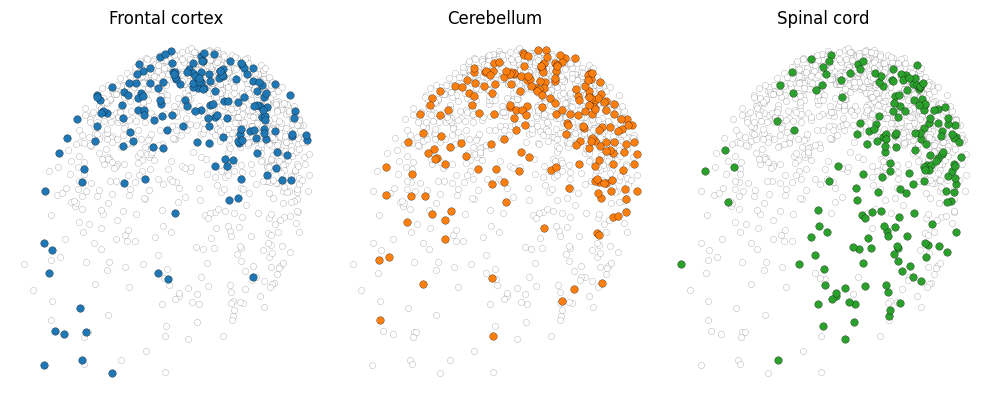

In [52]:
# Visualize projection target in Joint PCA
print("Visualizing projection target in joint PCA space...")

# Setup colors
cate_list = ['Frontal Cortex', 'Cerebellum', 'Spinal Cord', 'NA']
cm = plt.cm.get_cmap('tab10')
default_colors = list(cm.colors)
col_list = default_colors[:3]
col_dict = {cate_list[i]: col_list[i] for i in range(len(cate_list))[:3]}
col_dict['others'] = 'white'

# Extract retroseq cells only
adata_subset = adata_concat[adata_concat.obs['batch'] == 'retro'].copy()
pca_coords = adata_subset.obsm['X_pca']

# Create plots for each projection target
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    # Highlight cells from this projection target
    mask = adata_subset.obs['injection_site'] == k
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], 
               color=col_dict[k], s=30, alpha=1, label=k,
               edgecolor='k', linewidth=.2)    
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure("injection_site_pca")


# summary hisogram btw pseudocluster and projection site

In [34]:
foo_df = adata_concat[adata_concat.obs['batch']=='retro'].obs[['pc','injection_site']]

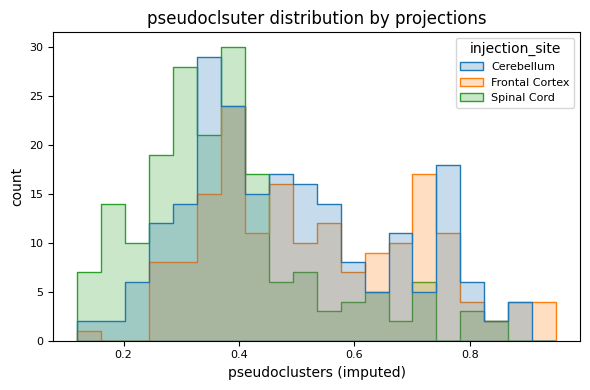

In [35]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(
    data=foo_df,
    bins=20,
    x='pc',
    hue='injection_site',
    element='step',
    stat='count',      # normalize heights for comparison
    common_norm=False    # keep separate normalization per group
)
plt.xlabel('pseudoclusters (imputed)')
plt.ylabel('count')
plt.title('pseudoclsuter distribution by projections')
plt.tight_layout()
plt.show()

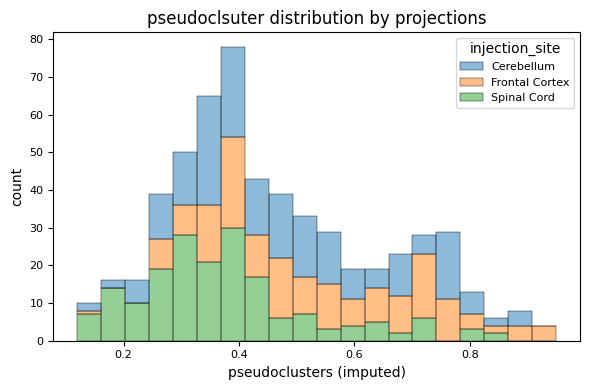

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=foo_df,
    bins=20,alpha = .5,linewidth=.3,
    x='pc',
    hue='injection_site',
     multiple="stack",
    stat='count',      # normalize heights for comparison
    common_norm=False    # keep separate normalization per group
)
plt.xlabel('pseudoclusters (imputed)')
plt.ylabel('count')
plt.title('pseudoclsuter distribution by projections')
plt.tight_layout()
plt.show()